In [0]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType

file_path = "/Volumes/bbim709_a1/bbim709_a1_schema/bbim709_a1_volume/ncr_ride_bookings.csv"

schema = StructType([
    StructField("Date", StringType(), True),
    StructField("Time", StringType(), True),
    StructField("Booking ID", StringType(), True),
    StructField("Booking Status", StringType(), True),
    StructField("Customer ID", StringType(), True),
    StructField("Vehicle Type", StringType(), True),
    StructField("Pickup Location", StringType(), True),
    StructField("Drop Location", StringType(), True),
    StructField("Avg VTAT", DoubleType(), True),
    StructField("Avg CTAT", DoubleType(), True),
    StructField("Cancelled Rides by Customer", IntegerType(), True),
    StructField("Reason for cancelling by Customer", StringType(), True),
    StructField("Cancelled Rides by Driver", IntegerType(), True),
    StructField("Driver Cancellation Reason", StringType(), True),
    StructField("Incomplete Rides", IntegerType(), True),
    StructField("Incomplete Rides Reason", StringType(), True),
    StructField("Booking Value", IntegerType(), True),
    StructField("Ride Distance", DoubleType(), True),
    StructField("Driver Ratings", DoubleType(), True),
    StructField("Customer Rating", DoubleType(), True),
    StructField("Payment Method", StringType(), True)
])

raw_df = (spark.read
          .option("header", "true")
          .option("nullValue", "null")
          .schema(schema)
          .csv(file_path))
raw_df.printSchema()
display(raw_df.limit(10))


root
 |-- Date: string (nullable = true)
 |-- Time: string (nullable = true)
 |-- Booking ID: string (nullable = true)
 |-- Booking Status: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Vehicle Type: string (nullable = true)
 |-- Pickup Location: string (nullable = true)
 |-- Drop Location: string (nullable = true)
 |-- Avg VTAT: double (nullable = true)
 |-- Avg CTAT: double (nullable = true)
 |-- Cancelled Rides by Customer: integer (nullable = true)
 |-- Reason for cancelling by Customer: string (nullable = true)
 |-- Cancelled Rides by Driver: integer (nullable = true)
 |-- Driver Cancellation Reason: string (nullable = true)
 |-- Incomplete Rides: integer (nullable = true)
 |-- Incomplete Rides Reason: string (nullable = true)
 |-- Booking Value: integer (nullable = true)
 |-- Ride Distance: double (nullable = true)
 |-- Driver Ratings: double (nullable = true)
 |-- Customer Rating: double (nullable = true)
 |-- Payment Method: string (nullable = true)



Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
2024-03-23,12:29:38,"""""""CNR5884300""""""",No Driver Found,"""""""CID1982111""""""",eBike,Palam Vihar,Jhilmil,null,null,null,null,null,null,null,null,null,null,null,null,null
2024-11-29,18:01:39,"""""""CNR1326809""""""",Incomplete,"""""""CID4604802""""""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,null,null,null,null,1,Vehicle Breakdown,237,5.73,null,null,UPI
2024-08-23,08:56:10,"""""""CNR8494506""""""",Completed,"""""""CID9202816""""""",Auto,Khandsa,Malviya Nagar,13.4,25.8,null,null,null,null,null,null,627,13.58,4.9,4.9,Debit Card
2024-10-21,17:17:25,"""""""CNR8906825""""""",Completed,"""""""CID2610914""""""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,null,null,null,null,null,null,416,34.02,4.6,5.0,UPI
2024-09-16,22:08:00,"""""""CNR1950162""""""",Completed,"""""""CID9933542""""""",Bike,Ghitorni Village,Khan Market,5.3,19.6,null,null,null,null,null,null,737,48.21,4.1,4.3,UPI
2024-02-06,09:44:56,"""""""CNR4096693""""""",Completed,"""""""CID4670564""""""",Auto,AIIMS,Narsinghpur,5.1,18.1,null,null,null,null,null,null,316,4.85,4.1,4.6,UPI
2024-06-17,15:45:58,"""""""CNR2002539""""""",Completed,"""""""CID6800553""""""",Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,null,null,null,null,null,null,640,41.24,4.0,4.1,UPI
2024-03-19,17:37:37,"""""""CNR6568000""""""",Completed,"""""""CID8610436""""""",Auto,Mayur Vihar,Cyber Hub,12.1,16.5,null,null,null,null,null,null,136,6.56,4.4,4.2,UPI
2024-09-14,12:49:09,"""""""CNR4510807""""""",No Driver Found,"""""""CID7873618""""""",Go Sedan,Noida Sector 62,Noida Sector 18,null,null,null,null,null,null,null,null,null,null,null,null,null
2024-12-16,19:06:48,"""""""CNR7721892""""""",Incomplete,"""""""CID5214275""""""",Auto,Rohini,Adarsh Nagar,6.1,26.0,null,null,null,null,1,Other Issue,135,10.36,null,null,Cash


In [0]:
#Display the number of rows in the DataFrame
raw_df.count()

150000

In [0]:
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, regexp_replace, to_timestamp, concat, lit

#Removing the unwanted quotes from IDs
clean_df = (raw_df
    .withColumn("Booking ID", regexp_replace(col("Booking ID"), '"', ''))
    .withColumn("Customer ID", regexp_replace(col("Customer ID"), '"', ''))
    .withColumn("dt_string", concat(col("Date"), lit(" "), col("Time")))

    #Combining Date and Time columns to form a single timestamp column
    .withColumn("booking_ts", to_timestamp (col("dt_string"), "yyyy-MM-dd HH:mm:ss"))
    )

#Checking if the cleaning worked
clean_df.select("Booking ID", "Date", "Time", "booking_ts").show(5, truncate=False)

+----------+----------+--------+-------------------+
|Booking ID|Date      |Time    |booking_ts         |
+----------+----------+--------+-------------------+
|CNR5884300|2024-03-23|12:29:38|2024-03-23 12:29:38|
|CNR1326809|2024-11-29|18:01:39|2024-11-29 18:01:39|
|CNR8494506|2024-08-23|08:56:10|2024-08-23 08:56:10|
|CNR8906825|2024-10-21|17:17:25|2024-10-21 17:17:25|
|CNR1950162|2024-09-16|22:08:00|2024-09-16 22:08:00|
+----------+----------+--------+-------------------+
only showing top 5 rows


In [0]:
#Display the cleaned dataset
display(clean_df.limit(10))

Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,dt_string,booking_ts
2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,null,null,null,null,null,null,null,null,null,null,null,null,null,2024-03-23 12:29:38,2024-03-23T12:29:38.000Z
2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,null,null,null,null,1,Vehicle Breakdown,237,5.73,null,null,UPI,2024-11-29 18:01:39,2024-11-29T18:01:39.000Z
2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,null,null,null,null,null,null,627,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,2024-08-23T08:56:10.000Z
2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,null,null,null,null,null,null,416,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,2024-10-21T17:17:25.000Z
2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,null,null,null,null,null,null,737,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,2024-09-16T22:08:00.000Z
2024-02-06,09:44:56,CNR4096693,Completed,CID4670564,Auto,AIIMS,Narsinghpur,5.1,18.1,null,null,null,null,null,null,316,4.85,4.1,4.6,UPI,2024-02-06 09:44:56,2024-02-06T09:44:56.000Z
2024-06-17,15:45:58,CNR2002539,Completed,CID6800553,Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,null,null,null,null,null,null,640,41.24,4.0,4.1,UPI,2024-06-17 15:45:58,2024-06-17T15:45:58.000Z
2024-03-19,17:37:37,CNR6568000,Completed,CID8610436,Auto,Mayur Vihar,Cyber Hub,12.1,16.5,null,null,null,null,null,null,136,6.56,4.4,4.2,UPI,2024-03-19 17:37:37,2024-03-19T17:37:37.000Z
2024-09-14,12:49:09,CNR4510807,No Driver Found,CID7873618,Go Sedan,Noida Sector 62,Noida Sector 18,null,null,null,null,null,null,null,null,null,null,null,null,null,2024-09-14 12:49:09,2024-09-14T12:49:09.000Z
2024-12-16,19:06:48,CNR7721892,Incomplete,CID5214275,Auto,Rohini,Adarsh Nagar,6.1,26.0,null,null,null,null,1,Other Issue,135,10.36,null,null,Cash,2024-12-16 19:06:48,2024-12-16T19:06:48.000Z


In [0]:
from pyspark.sql.functions import date_format, col

#Renaming columns to replace spaces with underscore because Delta Lake does not support spaces in column names
new_names = [c.replace(" ", "_") for c in clean_df.columns]
renamed_df = clean_df.toDF(*new_names)

#Adding month column to partition the data by month 
final_df = renamed_df.withColumn("booking_month", date_format(col("booking_ts"), "yyyy-MM"))

#Saving the data to a Delta Lake table after partitioning by month
(final_df.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .partitionBy("booking_month")
    .saveAsTable("bbim709_a1.bbim709_a1_schema.ride_bookings"))

print("Saved. Tables in your schema:")
spark.sql("SHOW TABLES IN bbim709_a1.bbim709_a1_schema").show()

Saved. Tables in your schema:
+-----------------+-------------+-----------+
|         database|    tableName|isTemporary|
+-----------------+-------------+-----------+
|bbim709_a1_schema|  daily_rides|      false|
|bbim709_a1_schema|ride_bookings|      false|
+-----------------+-------------+-----------+



In [0]:
spark.sql("""
    OPTIMIZE bbim709_a1.bbim709_a1_schema.ride_bookings ZORDER BY (Vehicle_Type)
""").show(truncate=False)

+----+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|path|metrics                                                                                                                                                                                                                                                |
+----+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|    |{0, 0, {NULL, NULL, 0.0, 0, 0}, {NULL, NULL, 0.0, 0, 0}, 12, {minCubeSize(107374182400), {0, 0}, {12, 5399668}, 0, {0, 0}, 0, NULL}, NULL, 0, 0, 12, 12, false, 0, 0, 1781357609970, 1781357611083, 8, 0, NULL, {0, 0}, NULL, 24, 24,

In [0]:
#Reading the saved Delta table from the storage
rides = spark.table("bbim709_a1.bbim709_a1_schema.ride_bookings")
print("Total rows in DeltaLake table: ", rides.count())

#Proving the table is Delta and is partitioned by month
spark.sql("DESCRIBE DETAIL bbim709_a1.bbim709_a1_schema.ride_bookings")\
    .select("format", "numFiles", "sizeInBytes", "partitionColumns"). show(truncate=False)

#Checking the number of rides per month
spark.sql("""
    SELECT booking_month, COUNT(*) AS rides
    FROM bbim709_a1.bbim709_a1_schema.ride_bookings
    GROUP BY booking_month
    ORDER BY booking_month
""").show()

Total rows in DeltaLake table:  150000
+------+--------+-----------+----------------+
|format|numFiles|sizeInBytes|partitionColumns|
+------+--------+-----------+----------------+
|delta |12      |5399668    |[booking_month] |
+------+--------+-----------+----------------+

+-------------+-----+
|booking_month|rides|
+-------------+-----+
|      2024-01|12861|
|      2024-02|11927|
|      2024-03|12719|
|      2024-04|12199|
|      2024-05|12778|
|      2024-06|12440|
|      2024-07|12897|
|      2024-08|12636|
|      2024-09|12248|
|      2024-10|12651|
|      2024-11|12394|
|      2024-12|12250|
+-------------+-----+



In [0]:
from pyspark.sql.functions import to_date, col, count, sum as _sum, avg

rides = spark.table("bbim709_a1.bbim709_a1_schema.ride_bookings")

daily = (rides
    .withColumn("booking_date", to_date(col("booking_ts")))   #Map: the day is the key, this step extracts the key
    .groupBy("booking_date")                                  #Shuffle: this step gathers the same day records 
    .agg(
        count("*").alias("total_rides"),
         _sum("Booking_Value").alias("revenue"),
         avg("Ride_Distance").alias("avg_distance")           #Reduce: this step combines the values per day
    )
    .orderBy("booking_date"))

daily.show(10)
print("Number of days:", daily.count())

+------------+-----------+-------+------------------+
|booking_date|total_rides|revenue|      avg_distance|
+------------+-----------+-------+------------------+
|  2024-01-01|        414| 124057| 25.94492647058824|
|  2024-01-02|        389| 113427|24.997286821705416|
|  2024-01-03|        384| 116982|25.992453531598525|
|  2024-01-04|        414| 117045| 24.71551601423489|
|  2024-01-05|        416| 133692|24.742163120567373|
|  2024-01-06|        409| 175438|23.915305343511445|
|  2024-01-07|        437| 204168|25.609003322259124|
|  2024-01-08|        387| 112933|24.462743682310474|
|  2024-01-09|        434| 129157|23.969062499999993|
|  2024-01-10|        407| 126270|24.146206896551725|
+------------+-----------+-------+------------------+
only showing top 10 rows
Number of days: 365


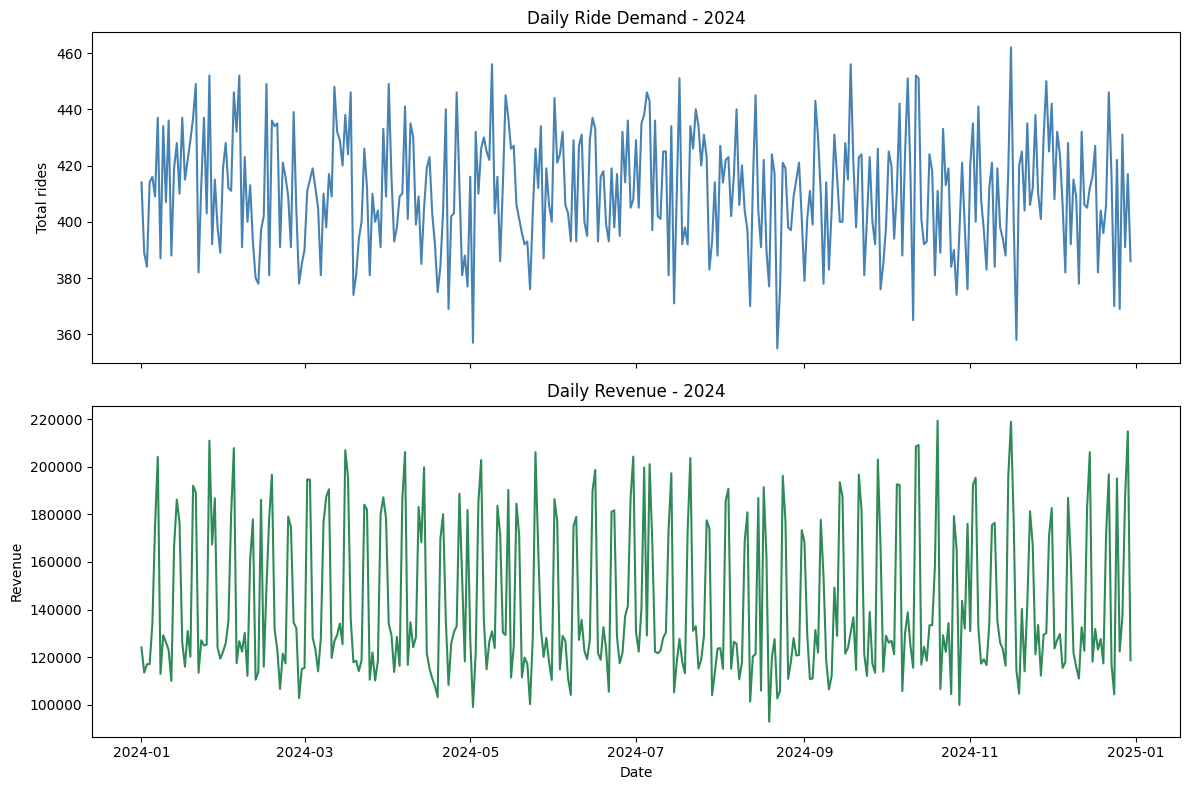

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import to_date, col, count, sum as _sum, avg

rides = spark.table("bbim709_a1.bbim709_a1_schema.ride_bookings")

# Optimized: filter on partition key booking_month for 2024 data
daily = (rides
    .filter(col("booking_month").like("2024-%"))
    .withColumn("booking_date", to_date(col("booking_ts")))
    .groupBy("booking_date")
    .agg(
        count("*").alias("total_rides"),
         _sum("Booking_Value").alias("revenue"),
         avg("Ride_Distance").alias("avg_distance")
    )
    .orderBy("booking_date"))

daily_pd = daily.toPandas()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(daily_pd["booking_date"], daily_pd["total_rides"], color="steelblue")
ax[0].set_title("Daily Ride Demand - 2024")
ax[0].set_ylabel("Total rides")

ax[1].plot(daily_pd["booking_date"], daily_pd["revenue"], color="seagreen")
ax[1].set_title("Daily Revenue - 2024")
ax[1].set_ylabel("Revenue")
ax[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [0]:
(daily.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("bbim709_a1.bbim709_a1_schema.daily_rides"))

print("Saved daily series.")
spark.sql("SELECT COUNT(*) AS days FROM bbim709_a1.bbim709_a1_schema.daily_rides").show()

Saved daily series.
+----+
|days|
+----+
| 365|
+----+



In [0]:
from pyspark.sql.functions import when, col, hour, dayofweek, month

rides = spark.table("bbim709_a1.bbim709_a1_schema.ride_bookings")

#Creating a new column where 1 represents a complted ride and 0 represents an unsecessfull ride 
df_ml = rides.withColumn("completed", when(col("Booking_Status") == "Completed", 1).otherwise(0))
#Extracting only the values that are known at booking time
df_ml = (df_ml
    .withColumn("hour", hour(col("booking_ts")))
    .withColumn("day_of_week", dayofweek(col("booking_ts")))
    .withColumn("month_num", month(col("booking_ts")))
    .select("Vehicle_Type", "hour", "day_of_week", "month_num", "completed"))

df_ml.show(5)
df_ml.groupBy("completed").count().show()

+------------+----+-----------+---------+---------+
|Vehicle_Type|hour|day_of_week|month_num|completed|
+------------+----+-----------+---------+---------+
|        Auto|   8|          6|        8|        1|
|        Auto|  16|          4|        8|        1|
|     Uber XL|   6|          5|        8|        1|
|        Auto|   7|          6|        8|        0|
|        Auto|  18|          3|        8|        0|
+------------+----+-----------+---------+---------+
only showing top 5 rows
+---------+-----+
|completed|count|
+---------+-----+
|        1|93000|
|        0|57000|
+---------+-----+



In [0]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

#1) Turning the "Vehicle_Type" from text to number
indexer = StringIndexer(inputCol="Vehicle_Type", outputCol="vehicle_idx")

#2) Converting the number into a one-hot vector
encoder = OneHotEncoder(inputCol="vehicle_idx", outputCol="vehicle_vec")

#3) Bundling every feature into one column named "features"
assembler = VectorAssembler(
    inputCols=["vehicle_vec", "hour", "day_of_week", "month_num"],
    outputCol="features")
    
#4) Split into training(80%) and testing (20%) sets
train, test = df_ml.randomSplit([0.8, 0.2], seed=42)
print("Training rows:", train.count())
print("Testing rows:", test.count())

Training rows: 120309
Testing rows: 29691


In [0]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier

# The model is a forset of 50 trees and each of them has a depth of up to 5
rf = RandomForestClassifier(
    labelCol="completed",
    featuresCol="features",
    numTrees=50,
    maxDepth=5,
    seed=42)

# Chain the prep steps and model them into one pipeline
pipeline = Pipeline(stages=[indexer, encoder, assembler, rf])

# Training the model
model = pipeline.fit(train)

# Predicting the unseen test set
predictions = model.transform(test)
predictions.select("completed", "prediction", "probability").show(10, truncate=False)

+---------+----------+----------------------------------------+
|completed|prediction|probability                             |
+---------+----------+----------------------------------------+
|1        |1.0       |[0.38531561283401755,0.6146843871659824]|
|0        |1.0       |[0.38697034049581136,0.6130296595041886]|
|1        |1.0       |[0.38697034049581136,0.6130296595041886]|
|1        |1.0       |[0.3843697865356857,0.6156302134643143] |
|1        |1.0       |[0.38215505032801567,0.6178449496719843]|
|1        |1.0       |[0.38215505032801567,0.6178449496719843]|
|0        |1.0       |[0.3836989103438858,0.6163010896561142] |
|1        |1.0       |[0.3836989103438858,0.6163010896561142] |
|1        |1.0       |[0.3836989103438858,0.6163010896561142] |
|1        |1.0       |[0.3814841741362158,0.6185158258637843] |
+---------+----------+----------------------------------------+
only showing top 10 rows


In [0]:
##Import Spark's built-in classification evaluation metrics
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

#Accuracy 
acc = MulticlassClassificationEvaluator(labelCol="completed", predictionCol="prediction", metricName="accuracy").evaluate(predictions)

#Precision
prec = MulticlassClassificationEvaluator(labelCol="completed", predictionCol="prediction", metricName="weightedPrecision").evaluate(predictions)

#Recall
rec = MulticlassClassificationEvaluator(labelCol="completed", predictionCol="prediction", metricName="weightedRecall").evaluate(predictions)

#F1 Score
f1 = MulticlassClassificationEvaluator(labelCol="completed", predictionCol="prediction", metricName="f1").evaluate(predictions)

#AUC
auc = BinaryClassificationEvaluator(labelCol="completed", rawPredictionCol="rawPrediction", metricName="areaUnderROC").evaluate(predictions)

print(f"Accuracy:{acc:.3f}")
print(f"Precision:{prec:.3f}")
print(f"Recall:{rec:.3f}")
print(f"F1 Score:{f1:.3f}")
print(f"auc:{auc:.3f}")

print ("\nConfusion matrix (Completed: Actual VS. Predicted):")
predictions.groupBy("completed", "prediction").count().orderBy("completed", "prediction").show()


Accuracy:0.621
Precision:0.386
Recall:0.621
F1 Score:0.476
auc:0.497

Confusion matrix (Completed: Actual VS. Predicted):
+---------+----------+-----+
|completed|prediction|count|
+---------+----------+-----+
|        0|       1.0|11256|
|        1|       1.0|18435|
+---------+----------+-----+



In [0]:
import os
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# UC volume path serverless to cache data during cross validation
os.environ["SPARKML_TEMP_DFS_PATH"] = "/Volumes/bbim709_a1/bbim709_a1_schema/bbim709_a1_volume/sparkml_tmp"

# Create the parameter grid
paramGrid = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 10])
    .build())

evaluator = BinaryClassificationEvaluator(labelCol="completed", metricName="areaUnderROC")

# Create the CrossValidator
cv = CrossValidator(estimator=pipeline,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator,
                    numFolds=3,
                    seed=42)

# Run cross validations
cv_model = cv.fit(train)

print("AUC for each combo:", [round(m, 3) for m in cv_model.avgMetrics])

best_index = cv_model.avgMetrics.index(max(cv_model.avgMetrics))
print("\nBest hyperparameters:")
for p, v in paramGrid[best_index].items():
    print(f"{p.name} = {v}")

best_auc = evaluator.evaluate(cv_model.transform(test))
print(f"\nBest model AUC on test set: {best_auc:.3f}")

AUC for each combo: [np.float64(0.501), np.float64(0.502), np.float64(0.5), np.float64(0.502)]

Best hyperparameters:
numTrees = 100
maxDepth = 10

Best model AUC on test set: 0.501


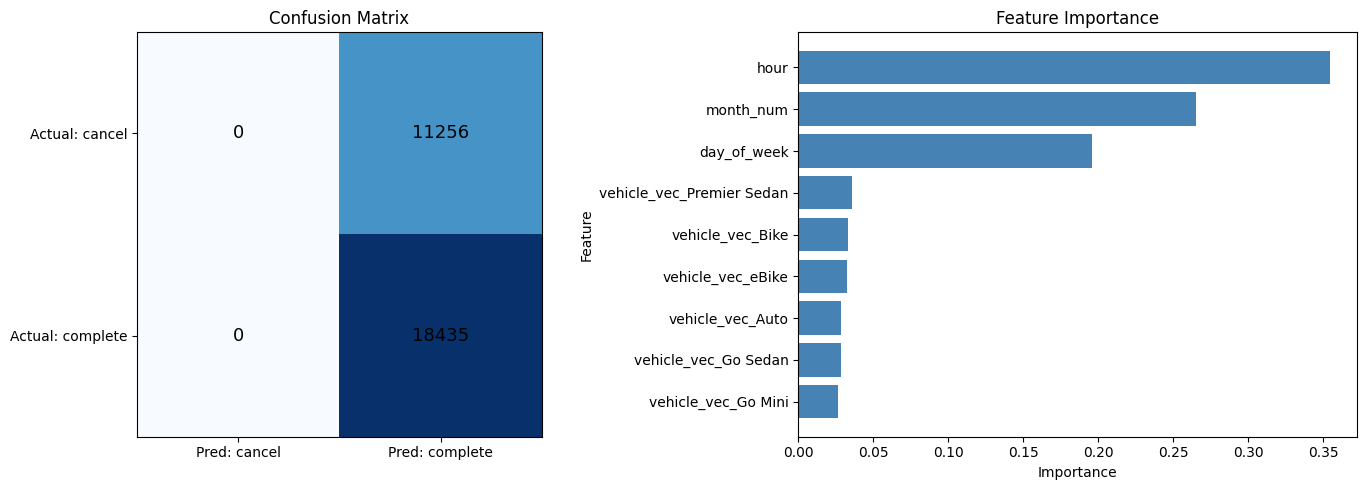

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Vialualization 1: Confusion Matrix
cm = predictions.groupBy("completed", "prediction").count().toPandas()
matrix = np.zeros((2, 2), dtype=int)
for _, r in cm.iterrows():
    matrix[int(r["completed"])][int(r["prediction"])] = r["count"]

#Visualization 2: Importing Features from the Tuned Model
rf_model = cv_model.bestModel.stages[-1]
importances = rf_model.featureImportances.toArray()
try:
    attrs = sorted(
        (a for grp in predictions.schema["features"].metadata["ml_attr"]["attrs"].values() for a in grp),
        key=lambda x: x["idx"])
    names = [a["name"] for a in attrs]
except Exception:
    names = [f"feature_{i}" for i in range(len(importances))]
imp = pd.DataFrame({"feature": names, "importance": importances}).sort_values("importance")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].imshow(matrix, cmap="Blues")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["Pred: cancel", "Pred: complete"])
ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(["Actual: cancel", "Actual: complete"])
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, matrix[i][j], ha="center", va="center", fontsize=13)
ax[0].set_title("Confusion Matrix")

ax[1].barh(imp["feature"], imp["importance"], color="steelblue")
ax[1].set_title("Feature Importance")
ax[1].set_xlabel("Importance")
ax[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [0]:
from pyspark.ml import Pipeline
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, dayofweek, month, when, col, avg

daily = spark.table("bbim709_a1.bbim709_a1_schema.daily_rides")

w = Window.orderBy("booking_date")

feat = (daily
    .withColumn("dow", dayofweek("booking_date"))
    .withColumn("is_weekend", when(dayofweek("booking_date").isin(1, 7), 1).otherwise(0))
    .withColumn("month_num", month("booking_date"))
    .withColumn("lag_1", lag("revenue", 1).over(w))
    .withColumn("lag_7", lag("revenue", 7).over(w))
    .withColumn("roll_7", avg("revenue").over(w.rowsBetween(-7, -1)))
    .dropna())

feat.select("booking_date", "revenue", "dow", "is_weekend", "lag_1", "lag_7", "roll_7").show(10)
print("Rows after feature engineering:", feat.count())

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+-------+---+----------+------+------+------------------+
|booking_date|revenue|dow|is_weekend| lag_1| lag_7|            roll_7|
+------------+-------+---+----------+------+------+------------------+
|  2024-01-08| 112933|  2|         0|204168|124057|          140687.0|
|  2024-01-09| 129157|  3|         0|112933|113427|139097.85714285713|
|  2024-01-10| 126270|  4|         0|129157|116982|          141345.0|
|  2024-01-11| 122917|  5|         0|126270|117045|142671.85714285713|
|  2024-01-12| 110001|  6|         0|122917|133692| 143510.7142857143|
|  2024-01-13| 166465|  7|         1|110001|175438| 140126.2857142857|
|  2024-01-14| 186217|  1|         1|166465|204168|138844.42857142858|
|  2024-01-15| 176623|  2|         0|186217|112933|          136280.0|
|  2024-01-16| 126234|  3|         0|176623|129157|145378.57142857142|
|  2024-01-17| 115925|  4|         0|126234|126270|          144961.0|
+------------+-------+---+----------+------+------+------------------+
only s

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor

assembler_r = VectorAssembler(
    inputCols=["dow", "is_weekend", "month_num", "lag_1", "lag_7", "roll_7"],
    outputCol="features")
    
train_r = feat.filter(col("booking_date") < "2024-11-01")
test_r = feat.filter(col("booking_date") >= "2024-11-01")
print("Train Days:", train_r.count(), "Test Days:", test_r.count())

rfr = RandomForestRegressor(labelCol="revenue", featuresCol="features", numTrees=100, maxDepth=6, seed=42)

pipeline_r = Pipeline(stages=[assembler_r, rfr])
model_r = pipeline_r.fit(train_r)

pred_r = model_r.transform(test_r)
pred_r.select("booking_date", "revenue", "prediction").show(10)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Train Days: 298 Test Days: 60
+------------+-------+------------------+
|booking_date|revenue|        prediction|
+------------+-------+------------------+
|  2024-11-01| 130954|117955.80026577886|
|  2024-11-02| 192376| 183248.8724784405|
|  2024-11-03| 195446| 181356.2577940597|
|  2024-11-04| 132092| 116280.5905907794|
|  2024-11-05| 117245|131775.23058073292|
|  2024-11-06| 119098|124659.98124891694|
|  2024-11-07| 116614|125739.87354991488|
|  2024-11-08| 133592| 122457.2943432136|
|  2024-11-09| 175474| 187941.7692413519|
|  2024-11-10| 176486|188922.75608399388|
+------------+-------+------------------+
only showing top 10 rows


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


RMSE : 17,979.46
MAE  : 12,061.94
R2   : 0.69


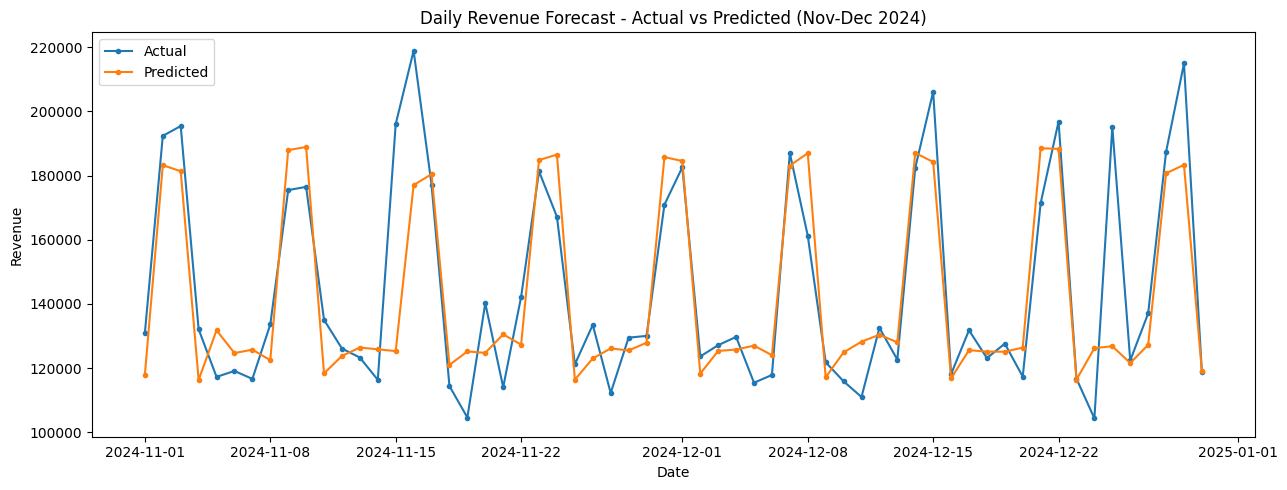

In [0]:
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt

for metric in ["rmse", "mae", "r2"]:
    val = RegressionEvaluator(labelCol="revenue", predictionCol="prediction", metricName=metric).evaluate(pred_r)
    print(f"{metric.upper():5s}: {val:,.2f}")

pdf = pred_r.select("booking_date", "revenue", "prediction").orderBy("booking_date").toPandas()
plt.figure(figsize=(13,5))
plt.plot(pdf["booking_date"], pdf["revenue"], label="Actual", marker="o", markersize=3)
plt.plot(pdf["booking_date"], pdf["prediction"], label="Predicted", marker="o", markersize=3)
plt.title("Daily Revenue Forecast - Actual vs Predicted (Nov-Dec 2024)")
plt.ylabel("Revenue");plt.xlabel("Date")
plt.tight_layout()
plt.legend()
plt.show()

In [0]:
import os 
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator

os.environ["SPARKML_TEMP_DFS_PATH"] = "/Volumes/bbim709_a1/bbim709_a1_schema/bbim709_a1_volume/sparkml_tmp"

grid_r = (ParamGridBuilder()
    .addGrid(rfr.numTrees, [50, 100, 150])
    .addGrid(rfr.maxDepth, [4,6,8])
    .build())

eval_rmse = RegressionEvaluator(labelCol="revenue", predictionCol="prediction", metricName="rmse")

cv_r = CrossValidator(estimator=pipeline_r,
                      estimatorParamMaps=grid_r,
                      evaluator=eval_rmse,
                      numFolds=3,
                      seed=42)

cv_model_r = cv_r.fit(train_r)

best_idx = cv_model_r.avgMetrics.index(min(cv_model_r.avgMetrics))
print("Best Hyperparameters:")
for p, v in grid_r[best_idx].items():
    print(f" {p.name} = {v}")

best_pred = cv_model_r.transform(test_r)
print("\nTuned model on test set:")
for metric in ["rmse", "mae", "r2"]:
    val = RegressionEvaluator(labelCol="revenue", predictionCol="prediction", metricName=metric).evaluate(best_pred)
    print(f" {metric.upper():5s}: {val:,.2f}")

print("\n(Untuned was: RMSE 17,979 and R2 0.69)")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Best Hyperparameters:
 numTrees = 50
 maxDepth = 4

Tuned model on test set:
 RMSE : 17,577.54
 MAE  : 11,528.92
 R2   : 0.70

(Untuned was: RMSE 17,979 and R2 0.69)


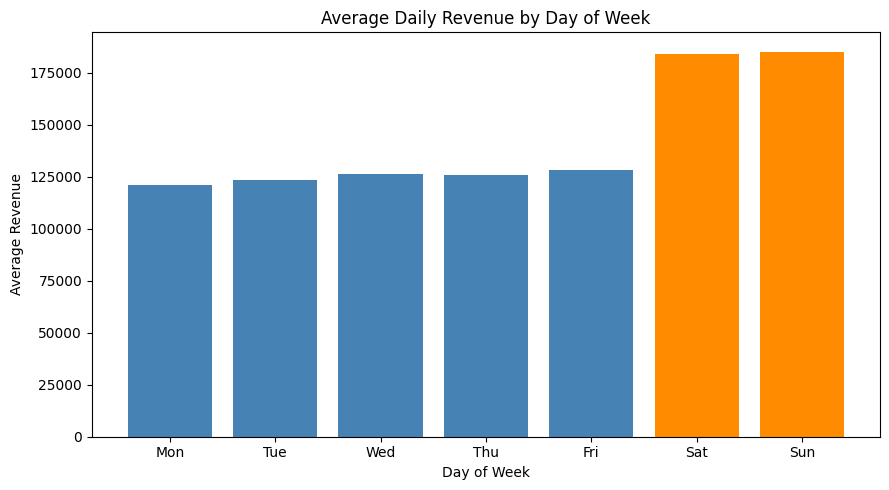

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import date_format, avg, col

daily = spark.table("bbim709_a1.bbim709_a1_schema.daily_rides")

#Each day's average revenue
dow_rev = (daily
    .withColumn("dow", date_format(col("booking_date"), "EEE"))
    .groupBy("dow")
    .agg(avg("revenue").alias("avg_revenue"))
    .toPandas())

#Forcing Monday to Sunday order
order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_rev["dow"] = pd.Categorical(dow_rev["dow"], categories=order, ordered=True)
dow_rev = dow_rev.sort_values("dow")

plt.figure(figsize=(9, 5))
colors=["steelblue"]*5 + ["darkorange"]*2 #This sets different colors for weekdays and weekends
plt.bar(dow_rev["dow"], dow_rev["avg_revenue"], color=colors)
plt.title("Average Daily Revenue by Day of Week")
plt.ylabel("Average Revenue")
plt.xlabel("Day of Week")
plt.tight_layout()
plt.show()

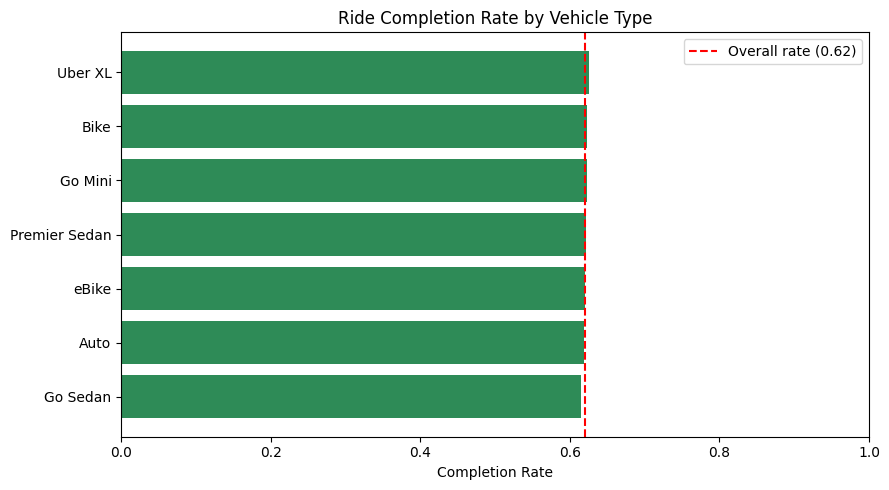

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import when, col, avg

rides = spark.table("bbim709_a1.bbim709_a1_schema.ride_bookings")

#Creating visualization of vehicle type completion rate
veh = (rides
    .withColumn("completed", when(col("Booking_Status") == "Completed", 1).otherwise(0))
    .groupBy("Vehicle_Type")
    .agg(avg("completed").alias("completion_rate"))
    .orderBy("completion_rate")
    .toPandas())

plt.figure(figsize=(9, 5))
plt.barh(veh["Vehicle_Type"], veh["completion_rate"], color="seagreen")
plt.axvline(0.62, color="red", linestyle="--", label="Overall rate (0.62)")
plt.title("Ride Completion Rate by Vehicle Type")
plt.xlabel("Completion Rate")
plt.xlim(0,1)
plt.legend()
plt.tight_layout()
plt.show()